Case 1
Y_pred_case1: tensor([  0, 100, 200, 300, 400, 500, 600, 700, 800, 900])

Case 2
Y_pred_case2: tensor([  0., 100., 200., 280., 360., 440., 520., 600., 680., 760.])

Case 3
Y_pred_case3: tensor([  0., 100., 200., 280., 360., 410., 460., 510., 560., 610.])

Case 4 (6 hidden ReLU units: Neural Skyline)
Y_pred_case4: tensor([0., 0., 4., 1., 1., 5., 0., 0., 0., 0.])

Case 6 (Case 3 with two width-2 hidden layers)
Y_pred_case6: tensor([  0., 100., 200., 280., 360., 410., 460., 510., 560., 610.])


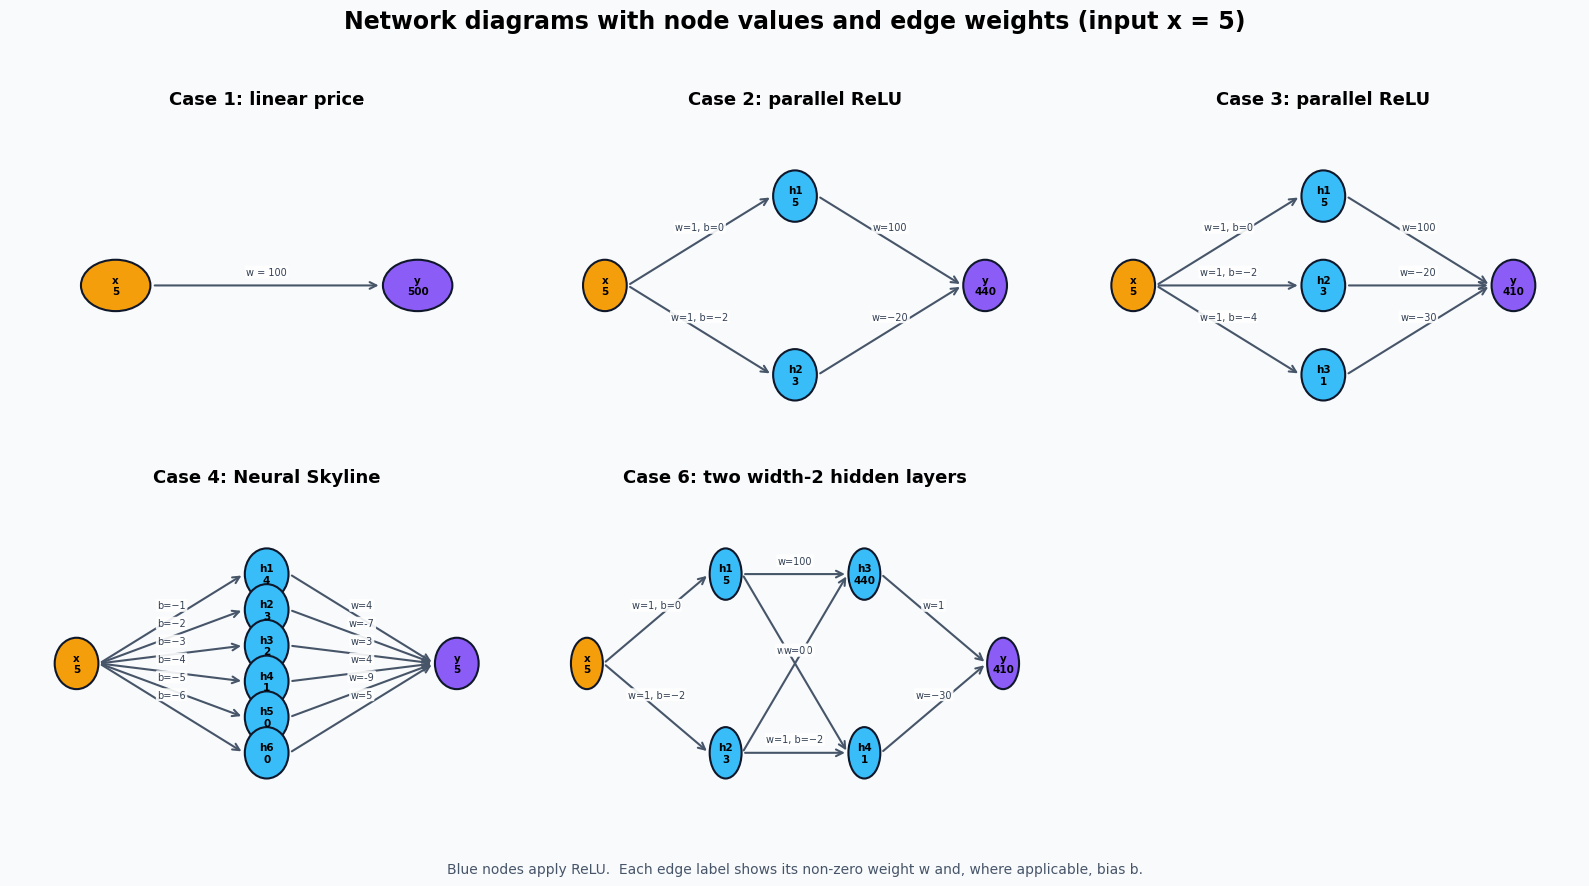

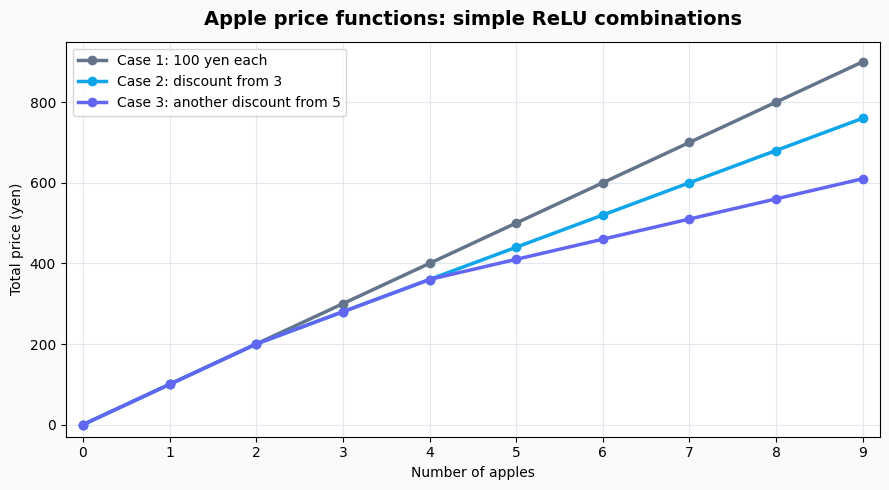

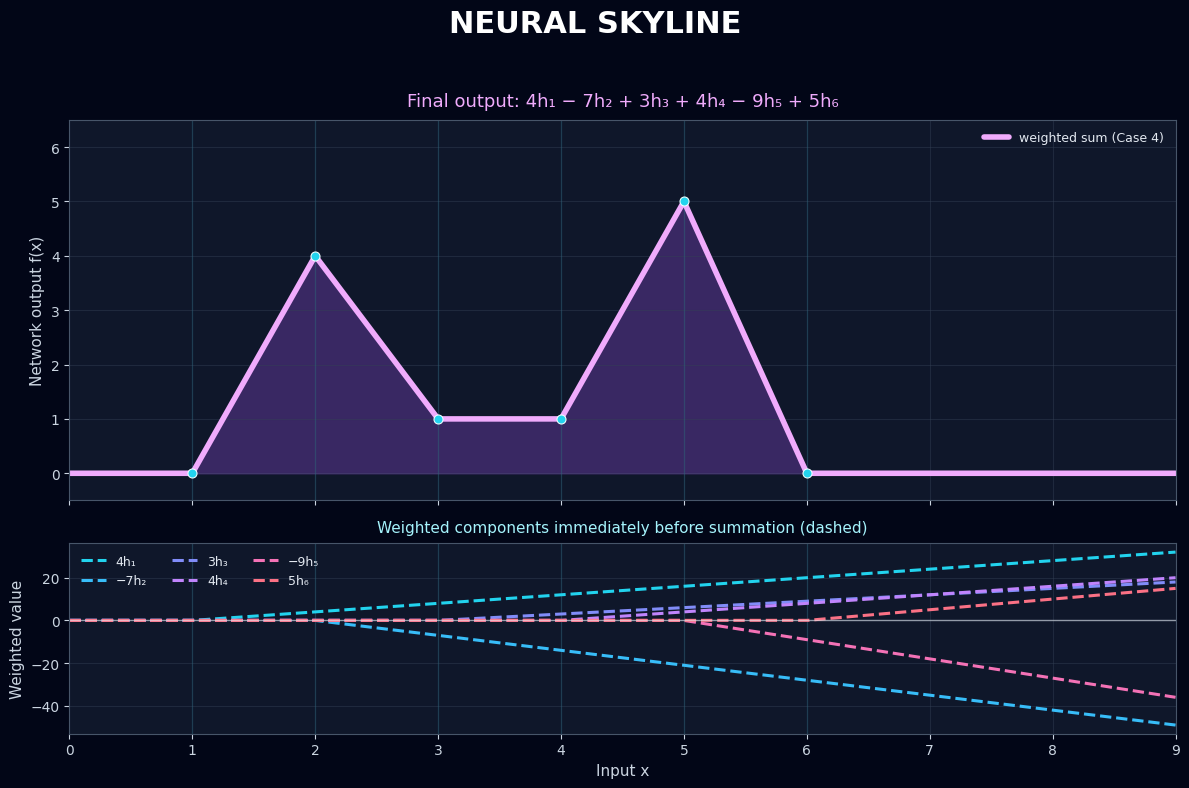

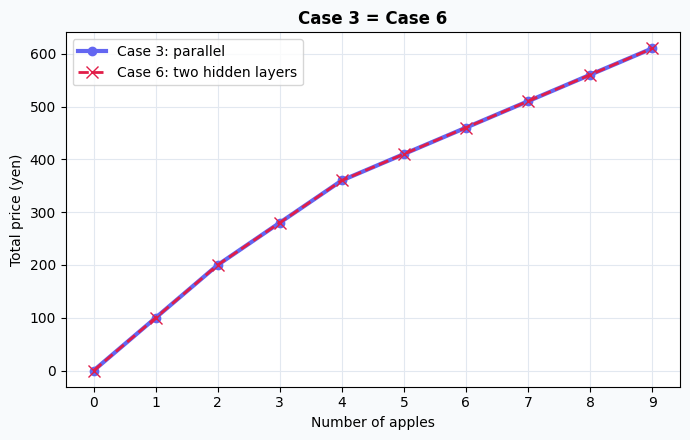

In [9]:
import torch
from torch import nn
import matplotlib.pyplot as plt


def relu(x):
    return torch.maximum(x, torch.tensor(0.0))


# ========================================
# データ
# ========================================

X = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


# ========================================
# ケース1
# すべてのりんごが1個100円
# ========================================

def case1_model(x):
    return 100 * x


Y_case1 = case1_model(X)

print("Case 1")
Y_pred_case1 = case1_model(X)
print(f"Y_pred_case1: {Y_pred_case1}")


# ========================================
# ケース2
# 2個までは1個100円
# 3個目以降は1個80円
# ========================================

def case2_model(x):
    h1 = relu(x)
    h2 = relu(x - 2)

    y = 100 * h1 - 20 * h2
    return y


Y_case2 = case2_model(X)

print("\nCase 2")
Y_pred_case2 = case2_model(X)
print(f"Y_pred_case2: {Y_pred_case2}")


# ========================================
# ケース3
# 2個までは1個100円
# 3〜4個目は1個80円
# 5個目以降は1個50円
# ========================================

def case3_model(x):
    h1 = relu(x)
    h2 = relu(x - 2)
    h3 = relu(x - 4)

    y = 100 * h1 - 20 * h2 - 30 * h3
    return y


Y_case3 = case3_model(X)

print("\nCase 3")
Y_pred_case3 = case3_model(X)
print(f"Y_pred_case3: {Y_pred_case3}")


# ========================================
# ケース4：6個のReLUで作る Neural Skyline
# 点線の単純なReLUを重み付きで足すと、太線の図形になる
# ========================================

def case4_model(x):
    h1 = relu(x - 1)
    h2 = relu(x - 2)
    h3 = relu(x - 3)
    h4 = relu(x - 4)
    h5 = relu(x - 5)
    h6 = relu(x - 6)

    return 4 * h1 - 7 * h2 + 3 * h3 + 4 * h4 - 9 * h5 + 5 * h6


Y_case4 = case4_model(X)

print("\nCase 4 (6 hidden ReLU units: Neural Skyline)")
Y_pred_case4 = case4_model(X)
print(f"Y_pred_case4: {Y_pred_case4}")


# ========================================
# ケース6：ケース3を2層・幅2の逐次ネットワークで表す
# ========================================

def case6_model(x):
    # 第1隠れ層：幅2
    h1 = relu(x)
    h2 = relu(x - 2)

    # 第2隠れ層：幅2
    h3 = relu(100 * h1 - 20 * h2)
    h4 = relu(0 * h1 + h2 - 2)  # h1 → h4 のエッジは重み0

    # 出力層
    y = h3 - 30 * h4
    return y

Y_case6 = case6_model(X)
print("\nCase 6 (Case 3 with two width-2 hidden layers)")
print(f"Y_pred_case6: {Y_case6}")


# ========================================
# ネットワーク図：ノードの値とエッジの係数
# すべて x = 5 を入力したときの具体例
# ========================================

from matplotlib.patches import Circle, FancyArrowPatch

def draw_network(ax, title, layers, edges):
    """layers: 各層の [(表示名, 値)]、edges: (始点層, 始点番号, 終点層, 終点番号, ラベル)"""
    ax.set_title(title, fontsize=13, weight="bold", pad=10)
    ax.set_xlim(-0.35, len(layers) - 0.65)
    ax.set_ylim(-0.25, 1.25)
    ax.axis("off")

    positions = {}
    for layer_index, layer in enumerate(layers):
        count = len(layer)
        y_values = [0.5] if count == 1 else torch.linspace(0.9, 0.1, count).tolist()
        for node_index, ((name, value), y) in enumerate(zip(layer, y_values)):
            positions[layer_index, node_index] = (layer_index, y)
            color = "#f59e0b" if layer_index == 0 else ("#8b5cf6" if layer_index == len(layers) - 1 else "#38bdf8")
            ax.add_patch(Circle((layer_index, y), 0.115, facecolor=color, edgecolor="#0f172a", linewidth=1.5, zorder=3))
            ax.text(layer_index, y, f"{name}\n{value:g}", ha="center", va="center", fontsize=7.5, weight="bold", zorder=4)

    for start_layer, start_node, end_layer, end_node, label in edges:
        x1, y1 = positions[start_layer, start_node]
        x2, y2 = positions[end_layer, end_node]
        arrow = FancyArrowPatch((x1 + 0.12, y1), (x2 - 0.12, y2), arrowstyle="->", mutation_scale=12,
                               linewidth=1.5, color="#475569", zorder=1)
        ax.add_patch(arrow)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.06, label, ha="center", va="center",
                fontsize=7, color="#334155", bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.9})

x_example = 5.0
fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor="#f8fafc")

draw_network(axes[0, 0], "Case 1: linear price",
             [[("x", x_example)], [("y", case1_model(torch.tensor(x_example)).item())]],
             [(0, 0, 1, 0, "w = 100")])

draw_network(axes[0, 1], "Case 2: parallel ReLU",
             [[("x", x_example)], [("h1", 5), ("h2", 3)], [("y", case2_model(torch.tensor(x_example)).item())]],
             [(0, 0, 1, 0, "w=1, b=0"), (0, 0, 1, 1, "w=1, b=−2"),
              (1, 0, 2, 0, "w=100"), (1, 1, 2, 0, "w=−20")])

draw_network(axes[0, 2], "Case 3: parallel ReLU",
             [[("x", x_example)], [("h1", 5), ("h2", 3), ("h3", 1)], [("y", case3_model(torch.tensor(x_example)).item())]],
             [(0, 0, 1, 0, "w=1, b=0"), (0, 0, 1, 1, "w=1, b=−2"), (0, 0, 1, 2, "w=1, b=−4"),
              (1, 0, 2, 0, "w=100"), (1, 1, 2, 0, "w=−20"), (1, 2, 2, 0, "w=−30")])

draw_network(axes[1, 0], "Case 4: Neural Skyline",
             [[("x", x_example)], [("h1", 4), ("h2", 3), ("h3", 2), ("h4", 1), ("h5", 0), ("h6", 0)], [("y", case4_model(torch.tensor(x_example)).item())]],
             [(0, 0, 1, i, f"b=−{i + 1}") for i in range(6)] +
             [(1, i, 2, 0, f"w={weight}") for i, weight in enumerate([4, -7, 3, 4, -9, 5])])

draw_network(axes[1, 1], "Case 6: two width-2 hidden layers",
             [[("x", x_example)], [("h1", 5), ("h2", 3)], [("h3", 440), ("h4", 1)], [("y", case6_model(torch.tensor(x_example)).item())]],
             [(0, 0, 1, 0, "w=1, b=0"), (0, 0, 1, 1, "w=1, b=−2"),
              (1, 0, 2, 0, "w=100"), (1, 1, 2, 0, "w=−20"), (1, 0, 2, 1, "w=0"), (1, 1, 2, 1, "w=1, b=−2"),
              (2, 0, 3, 0, "w=1"), (2, 1, 3, 0, "w=−30")])
axes[1, 2].axis("off")

fig.suptitle("Network diagrams with node values and edge weights (input x = 5)", fontsize=17, weight="bold", y=0.98)
fig.text(0.5, 0.02, "Blue nodes apply ReLU.  Each edge label shows its non-zero weight w and, where applicable, bias b.", ha="center", color="#475569")
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


# ========================================
# グラフ1：ケース1〜3（りんごの価格）
# ========================================

plt.figure(figsize=(9, 5), facecolor="#f8fafc")
plt.plot(X, Y_case1, "o-", color="#64748b", linewidth=2.5, label="Case 1: 100 yen each")
plt.plot(X, Y_case2, "o-", color="#0ea5e9", linewidth=2.5, label="Case 2: discount from 3")
plt.plot(X, Y_case3, "o-", color="#6366f1", linewidth=2.5, label="Case 3: another discount from 5")
plt.title("Apple price functions: simple ReLU combinations", fontsize=14, weight="bold", pad=12)
plt.xlabel("Number of apples")
plt.ylabel("Total price (yen)")
plt.xlim(-0.2, 9.2)
plt.xticks(range(0, 10))
plt.ylim(-30, 950)
plt.legend()
plt.grid(color="#e2e8f0")
plt.tight_layout()
plt.show()


# グラフ2：ケース4（加重済みのReLU成分と最終出力）
X_dense = torch.linspace(0, 9, 1000)
kinks = torch.tensor([1, 2, 3, 4, 5, 6])
weighted_components = [
    4 * relu(X_dense - 1), -7 * relu(X_dense - 2), 3 * relu(X_dense - 3),
    4 * relu(X_dense - 4), -9 * relu(X_dense - 5), 5 * relu(X_dense - 6),
]
component_labels = ["4h₁", "−7h₂", "3h₃", "4h₄", "−9h₅", "5h₆"]
unit_colors = ["#22d3ee", "#38bdf8", "#818cf8", "#c084fc", "#f472b6", "#fb7185"]

fig, (ax, ax_components) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                        gridspec_kw={"height_ratios": [2, 1]}, facecolor="#020617")
for current_ax in (ax, ax_components):
    current_ax.set_facecolor("#0f172a")
    current_ax.tick_params(colors="#cbd5e1")
    for spine in current_ax.spines.values():
        spine.set_color("#475569")
    current_ax.grid(color="#334155", alpha=0.45)
for x in kinks:
    ax.axvline(x.item(), color="#22d3ee", alpha=0.12, linewidth=1)
    ax_components.axvline(x.item(), color="#22d3ee", alpha=0.12, linewidth=1)
ax.fill_between(X_dense, case4_model(X_dense), color="#a855f7", alpha=0.28)
ax.plot(X_dense, case4_model(X_dense), color="#f0abfc", linewidth=4, solid_capstyle="round", label="weighted sum (Case 4)")
ax.scatter(kinks, case4_model(kinks), s=42, color="#22d3ee", edgecolor="#ecfeff", linewidth=0.8, zorder=5)
for component, label, color in zip(weighted_components, component_labels, unit_colors):
    ax_components.plot(X_dense, component, linestyle="--", color=color, linewidth=2.2, label=label)
ax_components.axhline(0, color="#e2e8f0", linewidth=1, alpha=0.6)

fig.suptitle("NEURAL SKYLINE", color="white", fontsize=22, weight="bold", y=0.98)
ax.set_title("Final output: 4h₁ − 7h₂ + 3h₃ + 4h₄ − 9h₅ + 5h₆", color="#f0abfc", fontsize=13, pad=10)
ax.set_ylabel("Network output f(x)", color="#cbd5e1", fontsize=11)
ax.set_ylim(-0.5, 6.5)
ax.legend(loc="upper right", fontsize=9, frameon=False, labelcolor="#e2e8f0")
ax_components.set_title("Weighted components immediately before summation (dashed)", color="#a5f3fc", fontsize=11, pad=8)
ax_components.set_xlabel("Input x", color="#cbd5e1", fontsize=11)
ax_components.set_ylabel("Weighted value", color="#cbd5e1", fontsize=11)
ax_components.set_xlim(0, 9)
ax_components.legend(loc="upper left", ncol=3, fontsize=9, frameon=False, labelcolor="#e2e8f0")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# グラフ3：ケース3とケース6は同じ価格関数を作る
fig, ax = plt.subplots(figsize=(7, 4.5), facecolor="#f8fafc")
ax.plot(X, Y_case3, "o-", color="#6366f1", linewidth=3, label="Case 3: parallel")
ax.plot(X, Y_case6, "x--", color="#e11d48", linewidth=2, markersize=8, label="Case 6: two hidden layers")
ax.set_title("Case 3 = Case 6", weight="bold")
ax.set_xlabel("Number of apples")
ax.set_ylabel("Total price (yen)")
ax.set_xticks(range(0, 10))
ax.legend()
ax.grid(color="#e2e8f0")
fig.tight_layout()
plt.show()
